In [45]:
import sys, os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
from jax.lib import xla_bridge
platform = xla_bridge.get_backend().platform
import jax
import jax.numpy as jnp
from jax import vmap, grad, pmap
print(jax.local_device_count(), jax.device_count())
jax.config.update('jax_platform_name', platform)
jax.config.update("jax_enable_x64", True)

import pathlib
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../../data/") 
abs_path_src = os.path.abspath(curr_path / "../../src/") 
abs_path_results = os.path.abspath(curr_path / "../../results/") 
abs_path_params = os.path.abspath(curr_path / "../../param_files/") 
sys.path.append((curr_path))
sys.path.append((abs_path_data))
sys.path.append((abs_path_results))
sys.path.append(os.path.join(str(abs_path_src), 'arxiv'))

import numpyro
numpyro.set_platform("gpu")
numpyro.enable_x64()
numpyro.set_host_device_count(jax.device_count())
from numpyro.handlers import seed, trace, condition
from numpyro.infer.reparam import LocScaleReparam, TransformReparam
from numpyro.infer import HMC, HMCECS, MCMC, NUTS, SA, SVI, Trace_ELBO, init_to_value

from jax import config
import scipy.interpolate as interp
import pickle as pk
import numpy as np
import colossus 
import configobj

from godmax.base_class import base_class
from godmax.get_radial_profiles import Profiles
from godmax.get_Pkzs import get_Pkz
from godmax.get_Cls import get_Cl
from godmax.get_Xis import get_xi
from godmax.get_covs import get_cov


# deproj = sys.argv[1]
# probe = sys.argv[2]
deproj = 'cib_1p7_dBeta'
probe = 'all'
try:
    smooth_ym_model = sys.argv[3]
except:
    smooth_ym_model = 'poweradd'


import yaml
from deepmerge import always_merger
def read_yaml(file_path):
    with open(file_path, 'r') as file:
        data = yaml.safe_load(file)
    return data

def generate_dicts(data):
    sim_params_dict = data.get('sim_params', {})
    halo_params_dict = data.get('halo_params', {})
    analysis_dict = data.get('analysis', {})
    other_params_dict = data.get('other_params', {})
    return sim_params_dict, halo_params_dict, analysis_dict, other_params_dict

default_data = read_yaml(abs_path_params + '/params_default.yaml')
new_data = read_yaml(abs_path_params + '/DESxACT/params_v0.yaml')
merged_data = always_merger.merge(default_data, new_data)

sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = generate_dicts(merged_data)

from astropy.io import fits
df = fits.open(os.path.abspath(abs_path_data + '/DESxACT/2pt_NG_final_2ptunblind_02_26_21_wnz_maglim_covupdate.fits'))
z_array = df['nz_source'].data['Z_MID']
nz_info_dict = {}
nz_info_dict['z_array_source'] = z_array
nz_info_dict['nbins'] = 4
for ji in range(nz_info_dict['nbins']):
    nz_info_dict['nz'+str(ji)] = np.maximum(df['nz_source'].data['BIN'+str(ji+1)], 1e-4)
analysis_dict['nz_source_info_dict'] = nz_info_dict
other_params_dict['Delta_z_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])
other_params_dict['mult_shear_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])

analysis_dict['angles_data_array'] = df['xip'].data['ANG'][0:20]

lmin, lmax, dl_log_array = 10.0, 81000.0, 0.23025851
l_array_all = np.exp(np.arange(np.log(lmin), np.log(lmax), dl_log_array))
dl_array = l_array_all[1:] - l_array_all[:-1]
l_array_survey = (l_array_all[1:] + l_array_all[:-1]) / 2.
halo_params_dict['ell_array'] = jnp.array(l_array_survey)
analysis_dict['l_array_survey'] = jnp.array(l_array_survey)
analysis_dict['dl_array_survey'] = jnp.array(dl_array)
analysis_dict['tSZ_transition_model'] = smooth_ym_model

deproj_to_true_y_file = {
    'None': 'ilc_SZ_yy',
    'cib_1p0': 'ilc_SZ_deproj_cib_1.0_10.7_yy',
    'cib_1p2': 'ilc_SZ_deproj_cib_1.2_10.7_yy',
    'cib_1p4': 'ilc_SZ_deproj_cib_1.4_10.7_yy',
    'cib_1p6': 'ilc_SZ_deproj_cib_1.6_10.7_yy',
    'cib_1p7': 'ilc_SZ_deproj_cib_1.7_10.7_yy',
    'cib_1p8': 'ilc_SZ_deproj_cib_1.8_10.7_yy',
    'cib_2p0': 'ilc_SZ_deproj_cib_2.0_10.7_yy',
    'cib_1p0_dBeta': 'ilc_SZ_deproj_cib_cibdBeta_1.0_10.7_yy',
    'cib_1p2_dBeta': 'ilc_SZ_deproj_cib_cibdBeta_1.2_10.7_yy',
    'cib_1p4_dBeta': 'ilc_SZ_deproj_cib_cibdBeta_1.4_10.7_yy',
    'cib_1p6_dBeta': 'ilc_SZ_deproj_cib_cibdBeta_1.6_10.7_yy',
    'cib_1p7_dBeta': 'ilc_SZ_deproj_cib_cibdBeta_1.7_10.7_yy',
    'cib_1p8_dBeta': 'ilc_SZ_deproj_cib_cibdBeta_1.8_10.7_yy',
    'cib_2p0_dBeta': 'ilc_SZ_deproj_cib_cibdBeta_2.0_10.7_yy',
}

save_DV_dir = os.path.abspath(abs_path_data + '/DESxACT/DV_v2/')
df_measure = pk.load(open(f'{save_DV_dir}/DESxACT_gty_xip_xim_DV_{deproj_to_true_y_file[deproj]}.pk', 'rb'))
cov_total = df_measure['cov_total']
xi_all = df_measure['xi_all']
theta_all = df_measure['theta_all']
cov_total = jnp.array(cov_total)
data_vec = jnp.array(xi_all)


cov_total = jnp.array(cov_total)
data_vec = jnp.array(xi_all)


if probe == 'xip_xim':
    cov_total = cov_total[80:, 80:]
    data_vec = data_vec[80:]
elif probe == 'gty':
    cov_total = cov_total[:80, :80]
    data_vec = data_vec[:80]

P_total = jnp.linalg.inv(cov_total)

from numpyro.distributions.transforms import AffineTransform
import numpyro.distributions as dist
import numpyro
def Uniform(name, min_value, max_value):
    """ Creates a Uniform distribution in target range from a base
    distribution between [-3, 3]
    """
    s = (max_value - min_value) / 6.
    return numpyro.sample(
            name,
            dist.TransformedDistribution(
                dist.Uniform(-3., 3.),
                AffineTransform(min_value + 3.*s, s),
            ),
        )

df_cs = fits.open(abs_path_data + '/DESxACT/2pt_NG_final_2ptunblind_02_26_21_wnz_maglim_covupdate.fits') 
bin1_vals =  df_cs['xip'].data['BIN1'][::20]
bin2_vals =  df_cs['xip'].data['BIN2'][::20]
biny_vals = np.array([1,2,3,4])

index_gty = []
for js in range(80):
    index_gty.append([js%20 ,js//20])
index_gty = jnp.array(index_gty)

index_xip = []
for js in range(200):
    binv = js//20
    thetav = js%20
    index_xip.append([thetav ,bin1_vals[binv]-1, bin2_vals[binv]-1])
index_xip = jnp.array(index_xip)

index_xim = []
for js in range(200):
    binv = js//20
    thetav = js%20
    index_xim.append([thetav ,bin1_vals[binv]-1, bin2_vals[binv]-1])
index_xim = jnp.array(index_xim)

with open(abs_path_params + '/DESxACT/priors_v0.yaml', 'r') as file:
    data = yaml.safe_load(file)
prior_limits = {key: tuple(map(float, value.split())) for key, value in data['prior_uniform'].items()}
prior_gaussian = {key: tuple(map(float, value.split())) for key, value in data['prior_gaussian'].items()}

prior_min_all_dict, prior_max_all_dict = {}, {}
for key in prior_limits.keys():
    prior_min_all_dict[key] = prior_limits[key][0]
    prior_max_all_dict[key] = prior_limits[key][1]

prior_mu_all_dict, prior_sig_all_dict = {}, {}
for key in prior_gaussian.keys():
    prior_mu_all_dict[key] = prior_gaussian[key][0]
    prior_sig_all_dict[key] = prior_gaussian[key][1]
prior_delta_z_mu_all = jnp.array([prior_mu_all_dict['Delta_z_bias_bin1'], prior_mu_all_dict['Delta_z_bias_bin2'], prior_mu_all_dict['Delta_z_bias_bin3'], prior_mu_all_dict['Delta_z_bias_bin4']])
prior_delta_z_sig_all = jnp.array([prior_sig_all_dict['Delta_z_bias_bin1'], prior_sig_all_dict['Delta_z_bias_bin2'], prior_sig_all_dict['Delta_z_bias_bin3'], prior_sig_all_dict['Delta_z_bias_bin4']])
prior_mult_shear_mu_all = jnp.array([prior_mu_all_dict['mult_shear_bias_bin1'], prior_mu_all_dict['mult_shear_bias_bin2'], prior_mu_all_dict['mult_shear_bias_bin3'], prior_mu_all_dict['mult_shear_bias_bin4']])
prior_mult_shear_sig_all = jnp.array([prior_sig_all_dict['mult_shear_bias_bin1'], prior_sig_all_dict['mult_shear_bias_bin2'], prior_sig_all_dict['mult_shear_bias_bin3'], prior_sig_all_dict['mult_shear_bias_bin4']])


cosmo_params_vary_names = ['Om0', 'sigma8', 'Ob0', 'h', 'ns']
sims_params_vary_names = ['theta_ej_0', 'nu_theta_ej_z', 'mu_beta', 'alpha_nt']
other_params_vary_names = ['alpha_ky', 'A_IA', 'eta_IA']
mult_shear_vary_names = ['mult_shear_bias_bin1', 'mult_shear_bias_bin2', 'mult_shear_bias_bin3', 'mult_shear_bias_bin4'] 
Delta_shear_vary_names = ['Delta_z_bias_bin1', 'Delta_z_bias_bin2', 'Delta_z_bias_bin3', 'Delta_z_bias_bin4']


from godmax.get_Xis import get_xi
import numpyro
import copy

def model():
    sim_params_dict_vary = copy.deepcopy(sim_params_dict)
    other_params_dict_vary = copy.deepcopy(other_params_dict)

    if len(cosmo_params_vary_names) > 0:
        for jp in range(len(cosmo_params_vary_names)):
            if cosmo_params_vary_names[jp] == 'h':
                fac = 100.
                cosmo_name = 'H0'
            else:
                fac = 1.
                cosmo_name = cosmo_params_vary_names[jp]
            prior_min_jp = prior_min_all_dict[cosmo_params_vary_names[jp]]
            prior_max_jp = prior_max_all_dict[cosmo_params_vary_names[jp]]
            sim_params_dict_vary['cosmo'][cosmo_name] = fac * Uniform(cosmo_params_vary_names[jp], prior_min_jp, prior_max_jp)

    if len(sims_params_vary_names) > 0:
        for jp in range(len(sims_params_vary_names)):
            prior_min_jp = prior_min_all_dict[sims_params_vary_names[jp]]
            prior_max_jp = prior_max_all_dict[sims_params_vary_names[jp]]
            sim_params_dict_vary[sims_params_vary_names[jp]] = Uniform(sims_params_vary_names[jp], prior_min_jp, prior_max_jp)
    
    if len(other_params_vary_names) > 0:
        for jp in range(len(other_params_vary_names)):
            prior_min_jp = prior_min_all_dict[other_params_vary_names[jp]]
            prior_max_jp = prior_max_all_dict[other_params_vary_names[jp]]
            other_params_dict_vary[other_params_vary_names[jp]] = Uniform(other_params_vary_names[jp], prior_min_jp, prior_max_jp)

    if len(prior_delta_z_mu_all) > 0:
        Delta_z_bias_array = numpyro.sample('Delta_z_bias_array', dist.Normal(prior_delta_z_mu_all, prior_delta_z_sig_all)) 
        other_params_dict_vary['Delta_z_bias_array'] = Delta_z_bias_array
    
    if len(prior_mult_shear_mu_all) > 0:
        mult_shear_bias_array = numpyro.sample('mult_shear_bias_array', dist.Normal(prior_mult_shear_mu_all, prior_mult_shear_sig_all))
        other_params_dict_vary['mult_shear_bias_array'] = mult_shear_bias_array
        
    get_corrfunc_BCMP_test = get_xi(sim_params_dict_vary, halo_params_dict, analysis_dict, other_params_dict_vary)

    def get_gty_from_index(index):
        index_val = index_gty[index]
        return get_corrfunc_BCMP_test.gty_out_mat[index_val[0], index_val[1]]

    def get_xip_from_index(index):
        index_val = index_xip[index]
        return get_corrfunc_BCMP_test.xip_out_mat[index_val[0], index_val[1], index_val[2]]

    def get_xim_from_index(index):
        index_val = index_xim[index]
        return get_corrfunc_BCMP_test.xim_out_mat[index_val[0], index_val[1], index_val[2]]

    gty_val = vmap(get_gty_from_index)(np.arange(80))
    xip_val = vmap(get_xip_from_index)(np.arange(200))
    xim_val = vmap(get_xim_from_index)(np.arange(200))

    if probe == 'xip_xim':
        mu = jnp.concatenate([xip_val, xim_val])
    elif probe == 'gty':
        mu = gty_val
    else:
        mu = jnp.concatenate([gty_val, xip_val, xim_val])
    return numpyro.sample('cl', dist.MultivariateNormal(mu, 
                                                        # precision_matrix=P_total,
                                                        covariance_matrix=cov_total))



observed_model = condition(model, {'cl': data_vec})


def config(x):
    if type(x['fn']) is dist.TransformedDistribution:
        return TransformReparam()
    elif type(x['fn']) is dist.Normal and ('decentered' not in x['name']):
        return LocScaleReparam(centered=0)
    else:
        return None

observed_model_reparam = numpyro.handlers.reparam(observed_model, config=config)




/tmp/ipykernel_1937086/3940551231.py:4: DeprecationWarning: jax.lib.xla_bridge.get_backend is deprecated; use jax.extend.backend.get_backend.
  platform = xla_bridge.get_backend().platform


1 1


In [11]:
from numpyro.infer import HMC, HMCECS, MCMC, NUTS, SA, SVI, Trace_ELBO, init_to_value
nuts_kernel = numpyro.infer.NUTS(observed_model_reparam,
                            step_size=5e-1, 
                            init_strategy=numpyro.infer.init_to_sample,
                            # init_strategy=numpyro.infer.init_to_value(values=custom_init_values_dict),                            
                            dense_mass=True,
                            max_tree_depth=4,
                            adapt_mass_matrix=True, 
                            adapt_step_size=True,
                            forward_mode_differentiation=False)

mcmc = numpyro.infer.MCMC(nuts_kernel, 
                          num_warmup=200, 
                          num_samples=200,
                          num_chains=16,
                          chain_method='vectorized',
                        #   chain_method='sequential',                          
                          progress_bar=True,
                          jit_model_args=True)





In [12]:
import jax

# mcmc.run(jax.random.PRNGKey(42), collect_diagnostics=True)
mcmc.run(jax.random.PRNGKey(42), extra_fields=("potential_energy",))




sample: 100%|██████████| 400/400 [11:41<00:00,  1.75s/it]  


In [13]:
df = {**mcmc.get_samples(), **mcmc.get_extra_fields()}



In [1]:
import pickle as pk
import numpy as np
df = pk.load(open('/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/chains_Jan/mcmc_probe_all_deproj_cib_1p7_dBeta_2500_6000_num_chains_80.pkl','rb'))
# df = pk.load(open('/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/chains_Jan/mcmc_probe_all_deproj_cib_1p7_dBeta_2000_4000_num_chains_32.pkl','rb'))
df.keys()



dict_keys(['A_IA', 'A_IA_base', 'Delta_z_bias_array', 'Delta_z_bias_array_decentered', 'Ob0', 'Ob0_base', 'Om0', 'Om0_base', 'alpha_ky', 'alpha_ky_base', 'alpha_nt', 'alpha_nt_base', 'diverging', 'eta_IA', 'eta_IA_base', 'h', 'h_base', 'mu_beta', 'mu_beta_base', 'mult_shear_bias_array', 'mult_shear_bias_array_decentered', 'ns', 'ns_base', 'nu_theta_ej_z', 'nu_theta_ej_z_base', 'potential_energy', 'sigma8', 'sigma8_base', 'theta_ej_0', 'theta_ej_0_base', 'prior_min', 'prior_max', 'fiducial_sims_params', 'fiducial_other_params', 'fiducial_halo_params', 'fiducial_analysis_params'])

In [2]:
import matplotlib.pyplot as pl
pl.rc('text', usetex=True)
# Palatino
# pl.rc('font', family='DejaVu Sans')
%matplotlib inline
import os

# os.environ['PATH'] += ':/projects/bdne/spandey3/tex/dtai/texlive/bin/aarch64-linux'



In [3]:
sig8 = df['sigma8']
nchains = 80
# nchains = 32
sig8_rs = sig8.reshape(nchains,-1)
# print(sig8_rs.shape)
from numpyro.diagnostics import autocorrelation, autocovariance

acorr = autocorrelation(sig8_rs, axis=1)
ind_del = []
for ji in range(acorr.shape[0]):
    if np.std(acorr[ji,100:]) > 0.06:
        ind_del.append(ji)
# autocovariance(sig8_rs).shape


In [4]:
print(len(ind_del), ind_del)


35 [4, 6, 7, 8, 9, 12, 13, 15, 24, 25, 27, 29, 30, 31, 32, 36, 37, 38, 40, 43, 45, 46, 48, 51, 52, 54, 55, 60, 61, 64, 67, 69, 75, 76, 77]


In [40]:
# # df['potential_energy'].shape
# # pl.plot(df['theta_ej_0'])
# # pl.plot(df['sigma8'])
# sig8 = df['sigma8']
# # sig8 = df['alpha_1h2h_ym']
# # sig8 = df['mu_beta']
# # sig8 = df['A_IA']
# # sig8 = df['theta_ej_0']
# nchains = 80
# sig8_rs = sig8.reshape(nchains,-1)
# # for ji in range(12):
#     # print(np.std(sig8_rs[ji]))
# # for ji in range(nchains):
# for ji in range(10):    
#     pl.figure()
#     pl.plot(sig8_rs[ji])
#     pl.title(ji)
#     print(np.mean(sig8_rs[ji]))
#     # pl.ylim(0.7, 1.0)
# pl.show()



(200000,)
(200000,)
(200000,)
(200000,)
(200000,)
(200000,)
(200000,)
(200000,)
(106875, 21) (45, 2375, 21)
Removed no burn in
1.0144583955744237 2321.366365175169


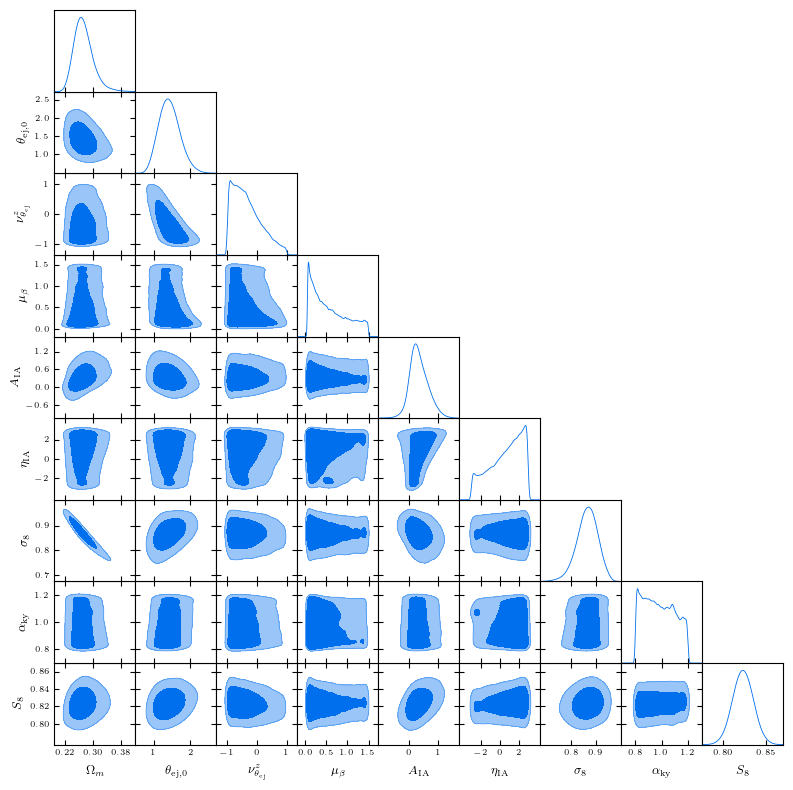

In [6]:
samps = []
keys = []
for key in df:
    if ('base' not in key) and ('decentered' not in key):
        if key not in ['prior_min', 'prior_max', 'fiducial_sims_params', 'fiducial_other_params', 'fiducial_halo_params', 'fiducial_analysis_params', 'diverging', 'potential_energy']:
            if ('Delta_z_bias_array' in key) or ('mult_shear_bias_array' in key):
                for jb in range(4):
                    samps.append(df[key][:, jb])
                    keys.append(key + '_' + str(jb))
                    print(df[key][:, jb].shape)
            # print(samps[0].shape)
            # print(df[key].shape)
            else:
                samps.append(df[key])
                keys.append(key)

samps = np.array(samps).T
ind_sigma8 = keys.index('sigma8')
# ind_thetaejM = keys.index('nu_theta_ej_M')
ind_Om = keys.index('Om0')
samp_S8 = samps[:,ind_sigma8] * (samps[:,ind_Om]/0.3)**0.5

samps = np.concatenate([samps, samp_S8[:,None]], axis=1)
keys.append('S8')

import getdist
from getdist import plots, MCSamples

names = keys

save_plot_dir = '/mnt/home/spandey/ceph/GODMAX/results/ACTxDES/'
labels_all = {'A_IA':r'$A_{\rm IA}$',
 'Ob0':r'$\Omega_b$',
 'Om0':r'$\Omega_m$',
 'eta_IA':r'$\eta_{\rm IA}$',
 'log10_Mc0':r'$\log(M_c)$',
 'theta_co_0':r'$\theta_{\rm co, 0}$',
 'gamma_rhogas':r'$\gamma$',
 'nu_z':r'$\nu_z$',
 'h':r'$h$',
 'ns':r'$n_s$',
 'mu_beta':r'$\mu_{\beta}$',
 'nu_theta_ej_M':r'$\nu^{M}_{\theta_{\rm ej}}$',
 'nu_theta_ej_z':r'$\nu^{z}_{\theta_{\rm ej}}$',
 'nu_theta_co_z':r'$\nu^{z}_{\theta_{\rm co}}$', 
 'log10_Mc0':r'$\log(M_c)$',
    'delta_rhogas':r'$\delta$',
    'gamma_rhogas':r'$\gamma$',
 'sigma8':r'$\sigma_8$',
 'theta_ej_0':r'$\theta_{\rm ej, 0}$',
 'S8':r'$S_8$',
 'alpha_nt':r'$\alpha_{\rm nt}$',
 'alpha_ky':r'$\alpha_{\rm ky}$',
 'alpha_kk':r'$\alpha_{\rm kk}$'
}

labels = []

for key in keys:
    if key in labels_all.keys():
        labels.append(labels_all[key])
    else:
        labels.append(r'm')

ind_frac_rm = 0.05
# nchains = 80
samps_sel = samps.reshape(nchains,-1, samps.shape[-1])
nsamp_per_chain = samps_sel.shape[1]
nrm = int(ind_frac_rm * nsamp_per_chain)
samps_sel = samps_sel[:, nrm:, :]

# # ind_del = np.array([4, 10])
# # ind_del = np.array([3])
# # ind_del = np.array([1,2,4,7])
# # ind_del = np.array([0,7,8,9,10])
# ind_del = [0]
# # ind_del = [3,5,8]
# # ind_del = [0,3,4,5,6,7,8,9,10,11]
if len(ind_del) > 0:
    samps_sel = np.delete(samps_sel, ind_del, axis=0)
else:
    samps_sel = samps_sel

samps = samps_sel.reshape(-1, samps_sel.shape[-1])
print(samps.shape, samps_sel.shape)

# saved = {'samps':samps, 'keys':keys, 'labels':labels, 'names':names}
# savedir = '/projects/bdne/spandey3/GODMAX/results/ACTxDES/'
# pk.dump(saved, open(savedir + 'samps_probes_all_npfNov_response_response.pkl', 'wb'))

# samps = samps[60000:80000,:]
samples = MCSamples(samples=samps,names = names, labels = labels)

from numpyro.diagnostics import gelman_rubin, effective_sample_size
ind_gr = ind_sigma8
gr = gelman_rubin(samps[:, ind_gr].reshape(samps_sel.shape[0], -1))
ess = effective_sample_size(samps[:, ind_gr].reshape(samps_sel.shape[0], -1))
print(gr, ess)

# pl.figure()
# for ji in range(samps_sel.shape[0]):
    # print(ji, np.std(samps_sel[ji, :, ind_thetaejM]), np.mean(samps_sel[ji, :, ind_thetaejM]))
    # pl.plot(samps_sel[ji, :, ind_thetaejM], alpha=0.1)
# pl.savefig(save_plot_dir + 'temp.pdf')
# pl.show()
# params = ['Om0', 'nu_theta_ej_M',  'theta_ej_0', 'nu_theta_ej_z', 'theta_co_0', 'S8']
# params = ['Om0', 'nu_theta_ej_M',  'theta_ej_0', 'nu_theta_ej_z', 'theta_co_0', 'sigma8']
# params = ['Om0', 'nu_theta_ej_M',  'nu_theta_ej_z', 'sigma8']
# params = ['nu_theta_ej_M','nu_theta_ej_z','theta_ej_0','theta_co_0','gamma_rhogas', 'mu_beta', 'delta_rhogas','log10_Mc0', 'alpha_ky']
# params = ['Om0', 'theta_ej_0', 'nu_theta_ej_M','nu_theta_ej_z','A_IA', 'eta_IA', 'alpha_nt', 'alpha_ky', 'alpha_kk', 'sigma8']
# params = ['Om0', 'nu_theta_ej_M','nu_theta_ej_z','A_IA', 'eta_IA', 'alpha_nt', 'alpha_ky', 'alpha_kk', 'sigma8']
# params = ['Om0', 'nu_theta_ej_M', 'gamma_rhogas', 'nu_theta_ej_z','A_IA', 'eta_IA', 'alpha_nt', 'sigma8']
# params = ['Om0', 'nu_theta_ej_M', 'mu_beta', 'nu_theta_ej_z','A_IA', 'eta_IA', 'alpha_nt', 'sigma8']
# params = ['Om0', 'theta_ej_0', 'mu_beta', 'nu_theta_ej_z','A_IA', 'eta_IA', 'alpha_nt', 'sigma8','alpha_1h2h_ym']
# params = ['Om0', 'theta_ej_0', 'mu_beta', 'nu_theta_ej_z','A_IA', 'eta_IA', 'alpha_nt', 'sigma8']
# params = ['Om0', 'theta_ej_0', 'nu_theta_ej_M', 'nu_theta_ej_z','A_IA', 'eta_IA', 'sigma8']
params = ['Om0', 'theta_ej_0', 'nu_theta_ej_z', 'mu_beta','A_IA', 'eta_IA', 'sigma8', 'alpha_ky', 'S8']
# params = ['Om0', 'nu_theta_ej_M', 'mu_beta', 'nu_theta_ej_z','A_IA', 'eta_IA', 'sigma8']
# params = ['Om0', 'theta_ej_0', 'A_IA', 'eta_IA', 'sigma8']
# params = ['Om0', 'nu_theta_ej_M', 'theta_co_0', 'sigma8', 'gamma_rhogas', 'S8']

g = plots.get_subplot_plotter(width_inch=8)
# g.triangle_plot([samples_xipxim, samples_gty, samples_all], params, filled=True)
g.triangle_plot([samples], params, filled=True)
# g.triangle_plot([samples], filled=True)

# g.export(save_plot_dir + 'xipm_simple_wide.pdf')
# save_plot_dir = '/projects/bdne/spandey3/GODMAX/results/plots/ACTxDES/'
# g.export(save_plot_dir + 'test_fix_thetaej_mubeta.pdf')
# g.export(save_plot_dir + 'test_vary_thetaej_mubeta_all_npf_response_response.pdf')
# 
import matplotlib
%matplotlib inline
pl.show()



In [1]:
from getdist import MCSamples
def get_param_names(filename):
    with open(filename,"r") as fi:
        param_names = np.array((fi.readline()[1:].split()))
    return param_names

def replace_fancy(names, fancy_dic):
    output_names = []
    ind_data = []
    for ii in range(len(names)):
        if (names[ii] in fancy_dic):
            output_names.append(fancy_dic[names[ii]])
            ind_data.append(ii)
    return np.array(output_names), np.array(ind_data)
# fancy_dictionary = {'cosmological_parameters--omega_m':r'$\Omega_m$','cosmological_parameters--s8':r'$S_8$'} 
filename = '/projects/bdne/spandey3/GODMAX/results/ACTxDES/chain_1x2pt_lcdm_SR_maglim.txt'
data = np.loadtxt(filename)
weights = np.loadtxt(filename)[:,-1]
param_names = get_param_names(filename)
# 
fancy_dictionary = {'cosmological_parameters--omega_m':r'$\Omega_m$','COSMOLOGICAL_PARAMETERS--SIGMA_8':r'$\sigma_8$'} 
param_names_fancy, selection = replace_fancy(np.array(param_names), fancy_dictionary)

data_y3kp = data[:,selection]
param_names = param_names[selection]
param_names_fancy = param_names_fancy

data_Om = data_y3kp[:,0]
data_sigma8 = data_y3kp[:,1]
data_S8 = data_sigma8 * np.sqrt(data_Om/0.3)
data = np.column_stack((data_Om, data_sigma8, data_S8))

# all_data.append(data)

# samples_y3kp = MCSamples(samples=data_y3kp,\
#                     weights=weights, \
#                     names = ['Om0','sigma8'], labels = [r'$\Omega_m$', r'$\sigma_8$'])

samples_y3kp = MCSamples(samples=data,\
                    weights=weights, \
                    names = ['Om0','sigma8','S8'], labels = [r'$\Omega_m$', r'$\sigma_8$', r'$S_8$'])



NameError: name 'np' is not defined

In [ ]:
from getdist import MCSamples
def get_param_names(filename):
    with open(filename,"r") as fi:
        param_names = np.array((fi.readline()[1:].split()))
    return param_names

def replace_fancy(names, fancy_dic):
    output_names = []
    ind_data = []
    for ii in range(len(names)):
        if (names[ii] in fancy_dic):
            output_names.append(fancy_dic[names[ii]])
            ind_data.append(ii)
    return np.array(output_names), np.array(ind_data)
# fancy_dictionary = {'cosmological_parameters--omega_m':r'$\Omega_m$','cosmological_parameters--s8':r'$S_8$'} 
filename = '/projects/bdne/spandey3/GODMAX/data/DESxACT/chain_p-TTTEEE-lowE_lcdm.txt'
data = np.loadtxt(filename)
weights = np.loadtxt(filename)[:,-1]
param_names = get_param_names(filename)
# 
fancy_dictionary = {'cosmological_parameters--omega_m':r'$\Omega_m$','COSMOLOGICAL_PARAMETERS--SIGMA_8':r'$\sigma_8$'} 
param_names_fancy, selection = replace_fancy(np.array(param_names), fancy_dictionary)

data_y3kp = data[:,selection]
param_names = param_names[selection]
param_names_fancy = param_names_fancy

data_Om = data_y3kp[:,0]
data_sigma8 = data_y3kp[:,1]
data_S8 = data_sigma8 * np.sqrt(data_Om/0.3)
data = np.column_stack((data_Om, data_sigma8, data_S8))

# all_data.append(data)

# samples_y3kp = MCSamples(samples=data_y3kp,\
#                     weights=weights, \
#                     names = ['Om0','sigma8'], labels = [r'$\Omega_m$', r'$\sigma_8$'])

samples_planck = MCSamples(samples=data,\
                    weights=weights, \
                    names = ['Om0','sigma8','S8'], labels = [r'$\Omega_m$', r'$\sigma_8$', r'$S_8$'])



In [2]:
from getdist import MCSamples
def get_param_names(filename):
    with open(filename,"r") as fi:
        param_names = np.array((fi.readline()[1:].split()))
    return param_names

def replace_fancy(names, fancy_dic):
    output_names = []
    ind_data = []
    for ii in range(len(names)):
        if (names[ii] in fancy_dic):
            output_names.append(fancy_dic[names[ii]])
            ind_data.append(ii)
    return np.array(output_names), np.array(ind_data)
# fancy_dictionary = {'cosmological_parameters--omega_m':r'$\Omega_m$','cosmological_parameters--s8':r'$S_8$'} 
filename1 = '/projects/bdne/spandey3/cs_godmax/cosmosis-standard-library/output/des-y3_shearonly_NLA_godmax_emcee.txt'
data1 = np.loadtxt(filename1)
weights1 = np.ones(data1.shape[0])

filename2 = '/projects/bdne/spandey3/cs_godmax/cosmosis-standard-library/output/des-y3_shearonly_NLA_godmax_emcee_2.txt'
data2 = np.loadtxt(filename2)
weights2 = np.ones(data2.shape[0])

filename3 = '/projects/bdne/spandey3/cs_godmax/cosmosis-standard-library/output/des-y3_shearonly_NLA_godmax_emcee_3.txt'
data3 = np.loadtxt(filename3)
weights3 = np.ones(data3.shape[0])

filename4 = '/projects/bdne/spandey3/cs_godmax/cosmosis-standard-library/output/des-y3_shearonly_NLA_godmax_emcee_4.txt'
data4 = np.loadtxt(filename4)
weights4 = np.ones(data4.shape[0])

data = np.concatenate((data1, data2, data3, data4), axis=0)
weights = np.concatenate((weights1, weights2, weights3, weights4))

print(data1.shape, data2.shape, data3.shape, data4.shape)

param_names = get_param_names(filename1)
# 
print(param_names)

fancy_dictionary = {'cosmological_parameters--omega_m':r'$\Omega_m$','COSMOLOGICAL_PARAMETERS--SIGMA_8':r'$\sigma_8$', 'shear_calibration_parameters--m4':r'$m_4$', 'wl_photoz_errors--bias_4':r'$\Delta z_4$'} 
param_names_fancy, selection = replace_fancy(np.array(param_names), fancy_dictionary)

data_y3kp = data[:,selection]
param_names = param_names[selection]
param_names_fancy = param_names_fancy

ind_Om = np.where(param_names == 'cosmological_parameters--omega_m')[0][0]
ind_sigma8 = np.where(param_names == 'COSMOLOGICAL_PARAMETERS--SIGMA_8')[0][0]
data_Om = data_y3kp[:,ind_Om]
data_sigma8 = data_y3kp[:,ind_sigma8]
data_S8 = data_sigma8 * np.sqrt(data_Om/0.3)
data = np.concatenate((data_y3kp, data_S8[:,None]), axis=-1)

# all_data.append(data)
indfac_burnin = 0.01
indstart = int(indfac_burnin*data.shape[0])

# samples_y3kp = MCSamples(samples=data_y3kp,\
#                     weights=weights, \
#                     names = ['Om0','sigma8'], labels = [r'$\Omega_m$', r'$\sigma_8$'])

samples_y3kp_nla = MCSamples(samples=data[indstart:,:],\
                    weights=weights[indstart:], \
                    names = ['Om0','mult_shear_bias_array_3', 'Delta_z_bias_array_3','sigma8', 'S8'], labels = [r'$\Omega_m$',r'$m_1$', r'$\Delta z_1$', r'$\sigma_8$', r'$S_8$'])




NameError: name 'np' is not defined

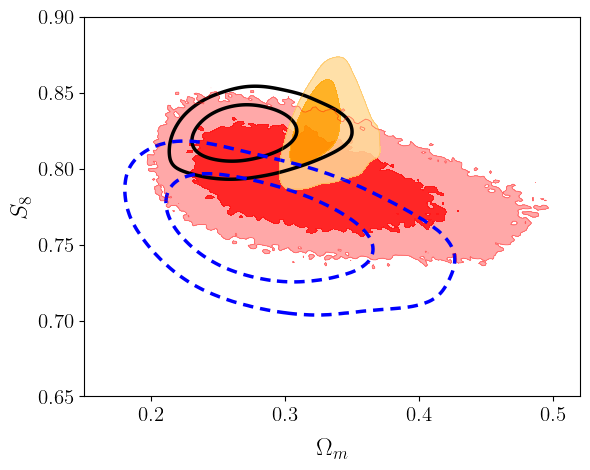

In [22]:
g = plots.getSinglePlotter(width_inch=6, ratio=0.8)
# g.settings.auto_ticks = True
g.settings.axes_fontsize   = 15
g.settings.lab_fontsize    = 18
g.settings.legend_fontsize = 18
g.settings.axis_marker_lw = 1.5
g.settings.num_plot_contours = 2

line_args = [{'lw':2.5,'color':'black'},{'lw':2.5,'color':'blue'},{'lw':0.1,'color':'red'},{'lw':0.1,'color':'orange'},{'lw':0.1,'color':'green'}]

contour_args = {'filled': True, 'alpha': 0.7}
# g.plot_2d([samples_all, samples_gty, samples_xipm, samples_y3kp], 'Om0', 'sigma8', line_args=line_args, 
#             contour_lws=[1.5], filled = [False, False,True, True, True], contour_colors = ['black','blue','red','orange','green'],
#             ls=['-','--','','',''] ,
#             lims=[0.13, 0.5, 0.58, 1.0])  

# g.plot_2d([samples, samples_y3kp], 'Om0', 'sigma8', line_args=line_args, 
#             contour_lws=[1.5], filled = [False, False,True, True, True], contour_colors = ['black','blue','red','orange','green'],
#             ls=['-','--','','',''] ,
            # lims=[0.13, 0.5, 0.58, 1.0])  

# g.plot_2d([samples, samples_y3kp, samples_y3kp_nla, samples_planck], 'Om0', 'sigma8', line_args=line_args, 
#             contour_lws=[1.5], filled = [False, False,True, True, True], contour_colors = ['black','blue','red','orange','green'],
#             ls=['-','--','','',''] ,
#             lims=[0.18, 0.52, 0.58, 1.1])  

g.plot_2d([samples, samples_y3kp, samples_y3kp_nla, samples_planck], 'Om0', 'S8', line_args=line_args, 
            contour_lws=[1.5], filled = [False, False,True, True, True], contour_colors = ['black','blue','red','orange','green'],
            ls=['-','--','','',''] ,
            lims=[0.15, 0.52, 0.65, 0.9])  

# g.add_legend([r'shear + shear$\times$tSZ',r'shear$\times$tSZ-only', r'shear-only',  r'Y3KP, shear-only'], legend_loc='upper right', fontsize=14)
# g.export(ldir + 'contour_Om0_sigma8_response_response.png', dpi=300)
import matplotlib
%matplotlib inline
pl.show()



In [42]:
df.keys()



dict_keys(['A_IA', 'A_IA_base', 'Delta_z_bias_array', 'Delta_z_bias_array_decentered', 'Ob0', 'Ob0_base', 'Om0', 'Om0_base', 'alpha_ky', 'alpha_ky_base', 'alpha_nt', 'alpha_nt_base', 'diverging', 'eta_IA', 'eta_IA_base', 'h', 'h_base', 'mu_beta', 'mu_beta_base', 'mult_shear_bias_array', 'mult_shear_bias_array_decentered', 'ns', 'ns_base', 'nu_theta_ej_z', 'nu_theta_ej_z_base', 'potential_energy', 'sigma8', 'sigma8_base', 'theta_ej_0', 'theta_ej_0_base', 'prior_min', 'prior_max', 'fiducial_sims_params', 'fiducial_other_params', 'fiducial_halo_params', 'fiducial_analysis_params'])

In [43]:
samps = []
keys = []
for key in df:
    if ('base' not in key) and ('decentered' not in key):
        if key not in ['prior_min', 'prior_max', 'fiducial_sims_params', 'fiducial_other_params', 'fiducial_halo_params', 'fiducial_analysis_params', 'diverging']:
            if ('Delta_z_bias_array' in key) or ('mult_shear_bias_array' in key):
                for jb in range(4):
                    samps.append(df[key][:, jb])
                    keys.append(key + '_' + str(jb))
                    print(df[key][:, jb].shape)
            else:
                samps.append(df[key])
                keys.append(key)            

samps = np.array(samps).T
ind_sigma8 = keys.index('sigma8')
ind_Om = keys.index('Om0')
samp_S8 = samps[:,ind_sigma8] * (samps[:,ind_Om]/0.3)**0.5

samps = np.concatenate([samps, samp_S8[:,None]], axis=1)
keys.append('S8')


ind_post = keys.index('potential_energy')
post = -1.* samps[:,ind_post]

map_ind = np.where(post == post.max())[0][0]

saved_bestift = {}
for jk, key in enumerate(keys):
    print(key, samps[map_ind, jk])
    saved_bestift[key] = samps[map_ind, jk]



(200000,)
(200000,)
(200000,)
(200000,)
(200000,)
(200000,)
(200000,)
(200000,)
A_IA 0.3794665112461789
Delta_z_bias_array_0 0.0012155748365686064
Delta_z_bias_array_1 -0.010290409865825108
Delta_z_bias_array_2 -0.004667117409719167
Delta_z_bias_array_3 0.003882608215013812
Ob0 0.03998385617559712
Om0 0.27306670845969927
alpha_ky 1.0569829709344967
alpha_nt 0.39193142332773073
eta_IA 0.4512748318990534
h 0.5610080256580252
mu_beta 0.4770498738426252
mult_shear_bias_array_0 -0.004030384413763002
mult_shear_bias_array_1 -0.021402383554478672
mult_shear_bias_array_2 -0.02764476253357268
mult_shear_bias_array_3 -0.035541103226412005
ns 1.0563604577265693
nu_theta_ej_z -0.3366105862071791
potential_energy -6752.116361110564
sigma8 0.8709250095272962
theta_ej_0 1.3141709474622179
S8 0.8309110074183431


In [46]:
other_params_dict['alpha_ky'] = 1.05698
other_params_dict['A_IA'] = 0.37946
other_params_dict['eta_IA'] = 0.451274
sim_params_dict['theta_ej_0'] =1.314170
sim_params_dict['nu_theta_ej_z'] = -0.33661058044
sim_params_dict['mu_beta'] = 0.47704987
sim_params_dict['alpha_nt'] = 0.39193
sim_params_dict['cosmo']['sigma8'] = 0.8709250
sim_params_dict['cosmo']['Om0'] = 0.273066708
sim_params_dict['cosmo']['ns'] = 1.05636045
sim_params_dict['cosmo']['Ob0'] =0.0399838
sim_params_dict['cosmo']['H0'] = 56.18



In [47]:
from godmax.base_class import base_class
from godmax.get_radial_profiles import Profiles
from godmax.get_Pkzs import get_Pkz
from godmax.get_Cls import get_Cl
from godmax.get_Xis import get_xi
from godmax.get_covs import get_cov

base_test = base_class(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)
profiles_test = Profiles(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, base_class_obj=base_test)
Pkz_test = get_Pkz(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Profiles_obj=profiles_test)
Cls_test = get_Cl(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Pkz_obj=Pkz_test)
xis_test = get_xi(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Cl_obj=Cls_test)
# cov_test = get_cov(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Cl_obj=Cls_test)





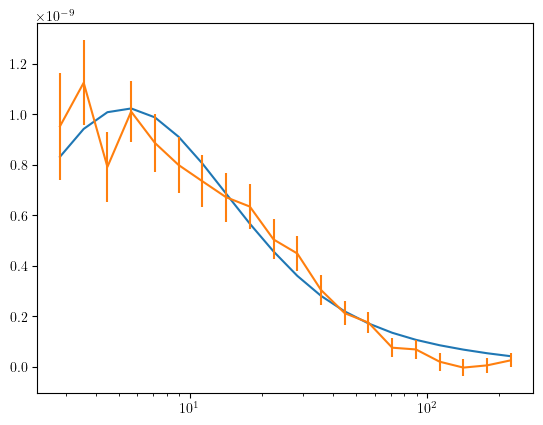

In [50]:
# xis_test.gty_out_mat.shape
bj = 2
sig_all = np.sqrt(np.diag(cov_total))
pl.figure()
pl.plot(analysis_dict['angles_data_array'], xis_test.gty_out_mat[:,bj])
pl.errorbar(analysis_dict['angles_data_array'], data_vec[20*bj:20*(bj+1)], yerr=sig_all[20*bj:20*(bj+1)])
# pl.yscale('log')
pl.xscale('log')
# xis_test.gty_out_mat.shape
# bj = 3
# indsel = np.where((bin1_all == bj) & (bin2_all == bj))[0]
# sig_all = np.sqrt(np.diag(cov_total))
# pl.figure()
# pl.plot(analysis_dict['angles_data_array'], xis_test.xip_out_mat[:,bj, bj])
# pl.errorbar(analysis_dict['angles_data_array'], xi_all[indsel][0:20], yerr=sig_all[indsel][0:20])
# pl.yscale('log')
# pl.xscale('log')
# pl.show()




In [51]:
h = sim_params_dict['cosmo']['H0'] / 100.0
Ob = sim_params_dict['cosmo']['Ob0']
Om = sim_params_dict['cosmo']['Om0']
import astropy.units as u
from astropy import constants as const
import jax_cosmo.background as bkgrd
sigmat = const.sigma_T
m_e = const.m_e
c = const.c
coeff = sigmat / (m_e * (c ** 2))
oneMpc_h_to_cm = (((10 ** 6)/h) * (u.pc).to(u.cm))
const_coeff = ((coeff).to(((u.kpc ** 2) / u.keV))).value

from scipy.interpolate import interp1d
import jax_cosmo.background as bkgrd
z_array = profiles_test.z_array
scale_fac_a_array = 1.0 / (1.0 + z_array)
indz = 0
Ez = np.sqrt(bkgrd.growth_factor(profiles_test.cosmo_jax, scale_fac_a_array))[indz]
# M200_noh = M_array[indM]/h
h70 = h/0.7
M_array = profiles_test.M_array
Y_model_all = np.zeros(len(M_array))
Y_ss_all = np.zeros(len(M_array))
for jM in range(len(M_array)):
    Mj = M_array[jM]
    M200_noh = Mj/h
    Y_ss = 97.6 * (1/h70) * (Ez**(2/3.)) * (M200_noh/(1e15/h70))**(5/3.) * (Ob/0.043) * (0.25/Om)

    # r200_jM = BCMP_test.r200c_mat[jM, indz]
    r200_jM = profiles_test.r200c_mat[jM, indz]    
    r_array_jM = np.logspace(-2, np.log10(r200_jM), 100)
    Pe_jz_jM = profiles_test.Pe_mat_physical[:, indz, jM]
    interpPe = interp1d(np.log(profiles_test.r_array), np.log(Pe_jz_jM), fill_value='extrapolate')
    Pe_jM = np.exp(interpPe(np.log(r_array_jM)))
    Y_jM = np.trapz(4 * np.pi * r_array_jM**2 * Pe_jM, r_array_jM)

    Y_model_all[jM] = const_coeff * Y_jM * (oneMpc_h_to_cm**3)
    Y_ss_all[jM] = Y_ss
    



/tmp/ipykernel_1937086/2487465373.py:34: RuntimeWarning: divide by zero encountered in log
  interpPe = interp1d(np.log(profiles_test.r_array), np.log(Pe_jz_jM), fill_value='extrapolate')
/tmp/ipykernel_1937086/2487465373.py:36: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  Y_jM = np.trapz(4 * np.pi * r_array_jM**2 * Pe_jM, r_array_jM)


In [11]:
pl.figure()
pl.plot(M_array, Y_model_all, label='Best-fit', lw=2.0)
pl.plot(M_array, 1.0e-24 * (M_array**(5/3.)), label=r'$\propto M^{5/3}$', lw=2.0, ls='--')
pl.xscale('log')
pl.yscale('log')
pl.xlabel(r'$M_{200c}$', fontsize=20)
pl.ylabel(r'$Y^{\rm 3D}_{\rm 200c}$', fontsize=20)
pl.xlim(1e13, 1.2e15)
pl.ylim(1e-3, 2e1)
pl.legend(fontsize=18)
pl.tick_params(axis='both', which='major', labelsize=16)
pl.tick_params(axis='both', which='minor', labelsize=16)
# pl.savefig('/mnt/home/spandey/ceph/GODMAX/results/ACTxDES/Y_M_bestfit.png', bbox_inches='tight', dpi=300)
pl.show()



NameError: name 'M_array' is not defined

<Figure size 640x480 with 0 Axes>

In [11]:
import configobj
import jax
import jax.numpy as jnp
import numpy as np
from astropy.io import fits
abs_path_data ='/projects/bdne/spandey3/new_godmax/GODMAX/data'
probe = 'xip_xim'
use_gty_scale_cuts = False
use_xipm_Y3_scale_cuts = False



In [12]:
fname = abs_path_data + '/DESxACT/scale_cuts_xipm_y3_gty_fid.ini'
config = configobj.ConfigObj(fname)
sc_xipm = config['shear-shear']
sc_gty = config['shear-tsz']

df_cs = fits.open(abs_path_data + '/DESxACT/2pt_NG_final_2ptunblind_02_26_21_wnz_maglim_covupdate.fits') 
bin1_vals =  df_cs['xip'].data['BIN1'][::20]
bin2_vals =  df_cs['xip'].data['BIN2'][::20]
biny_vals = np.array([1,2,3,4])
ang_vals = df_cs['xip'].data['ANG'][0:20]


def process_indices(num, bin_vals, angle_ranges, offset, probe, angle_type, do_scalecuts):
    indices, indrm = [], []
    for js in range(num):
        binv, thetav = divmod(js, 20)
        bin1, bin2 = (bin_vals[binv] - 1, bin_vals[binv] - 1) if angle_type != 'gty' else (None, None)
        if do_scalecuts:
            sc_min, sc_max = map(float, angle_ranges[binv].split())
        else:
            sc_min, sc_max = 1e-3, 999.0
        if sc_min < ang_vals[thetav] < sc_max:
            indices.append([int(thetav), int(bin1), int(bin2)] if bin1 is not None else [int(thetav), int(binv)])
        elif probe in [angle_type, 'all']:
            indrm.append(int(offset + js))
    return jnp.array(indices, dtype=jnp.int32), jnp.array(indrm, dtype=jnp.int32)

# Process gty indices
sc_ranges_gty = [sc_gty[f'angle_range_gty_{biny}_0'] for biny in biny_vals]
index_gty, indrm_gty = process_indices(80, None, sc_ranges_gty, 0, probe, 'gty', use_gty_scale_cuts)
len_ind_gty = len(index_gty)
# Process xip indices
sc_ranges_xip = [sc_xipm[f'angle_range_xip_{bin1}_{bin2}'] for bin1, bin2 in zip(bin1_vals, bin2_vals)]
offset_xip = 80 if probe in ['gty', 'all'] else 0
index_xip, indrm_xip = process_indices(200, bin1_vals, sc_ranges_xip, offset_xip, probe, 'xip_xim', use_xipm_Y3_scale_cuts)
len_ind_xip = len(index_xip)
# Process xim indices
sc_ranges_xim = [sc_xipm[f'angle_range_xim_{bin1}_{bin2}'] for bin1, bin2 in zip(bin1_vals, bin2_vals)]
offset_xim = 280 if probe in ['gty', 'all'] else 200
index_xim, indrm_xim = process_indices(200, bin1_vals, sc_ranges_xim, offset_xim, probe, 'xip_xim', use_xipm_Y3_scale_cuts)
len_ind_xim = len(index_xim)
# Combine results
indrm = jnp.concatenate([indrm_gty, indrm_xip, indrm_xim], dtype=jnp.int32)



In [13]:

indrm
# indrm_xip
# ang_vals

Array([], shape=(0,), dtype=int32)

In [14]:
# sc_xipm
len(indrm)


0